In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm import trange


In [261]:
# implementing neuron according to LIF by tracking state of V 
class LIFNeuron:
    def __init__(self, C=1.0, gL=0.1, EL=-70.0, V0=-70.0,sigma=0.01, Vth=-63.0, Vreset=-70.0, Vmax=30.0):

        # initial LIF parameters 
        self.C = C      # microF
        self.gL = gL    # microS
        self.EL = EL    # mV
        self.V = V0     # mV
        self.sigma = sigma 

        self.Vth = Vth
        self.Vreset = Vreset
        self.Vmax = Vmax
        self.sigma = sigma

    def dVdt(self, I):
        return (self.gL * (self.EL - self.V) + I) / self.C

    def step(self, I, dt):
        V_next = self.V + dt * self.dVdt(I) + np.random.normal() * self.sigma * np.sqrt(dt)

        # fire an action potential 
        if (V_next  >= self.Vth):
            self.V = self.Vreset
            return self.Vmax, 1 # returns 1 if there is a spike 
        
        self.V = V_next
        return self.V, 0 

In [239]:
# An helper method for generating integers in a given range (for connection weights)
def random_int_gen(low=-2, high=5, size=None):
    return np.random.randint(low, high, size=size)
    #return np.full(shape=size, fill_value=3)

# A class for connected neural clusters
class NeuralCluster():
    def __init__(self, N:int, density):
        # Size of the network
        self.N = N

        self.neurons = [LIFNeuron() for _ in range(N)]
        # Weights of the connection : sparse matrix of density d
        w_base = .1* np.diag(random_int_gen(size=N-1),k=1) # k =1 ensures no self connctions and a very sparse matrix 
        w_base[-1,0] = 10* random_int_gen() # creates the loop of wegihts 

        self.w = w_base + sp.sparse.random_array((N,N), density = density, data_sampler=random_int_gen)
        # initialize the array that will hold the firing rates (size 1xN)
        self.x = np.empty((1,N))
        # sigmoid activation function (uniform for all neurons in the cluster)
        self.fct = lambda y:1/(1+np.exp(-y))
        # External input is set to zero
        self.I = 0

    # Set the external input. Positive values = excitation
    def set_input(self, I):
        self.I = I

    def compute_dynamics_lif(self, V0, T, dt):
        n_steps = int(T/dt)

        self.t = dt * np.arange(n_steps)
        self.V = np.zeros((n_steps, self.N))

        # create neurons 
        for i, neuron in enumerate(self.neurons):
            neuron.V = V0[i]
            self.V[0, i] = V0[i]
            self.spike_trains = np.zeros((n_steps, self.N))

        # simulate dynamics in time 
        for k in trange(n_steps - 1, desc="Computing dynamics steps"):
            V_curr  = self.V[k]

            recurrent_input = self.w @ self.spike_trains[k]
            total_input = self.I + recurrent_input

            for i, neuron in enumerate(self.neurons):
                V_curr, spike = neuron.step(total_input[i],dt)
                self.V[k+1, i] = neuron.V
                self.spike_trains[k, i] = spike

    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spike_trains[:,i]
            event.append(np.nonzero(st)[0])
        plt.eventplot(event, colors='k', zorder = 0)

# Helper method to plot the dynamics (one color for the whole cluster)
def plot_dynamics(cluster, color):
    t = cluster.t
    x = cluster.x
    for i in range(cluster.N):
        plt.plot(t, x[:, i], c=color)
    plt.xlabel("Seconds [ms]")
    plt.ylabel("Rate")

Computing dynamics steps: 100%|██████████| 9999/9999 [00:00<00:00, 36740.51it/s]


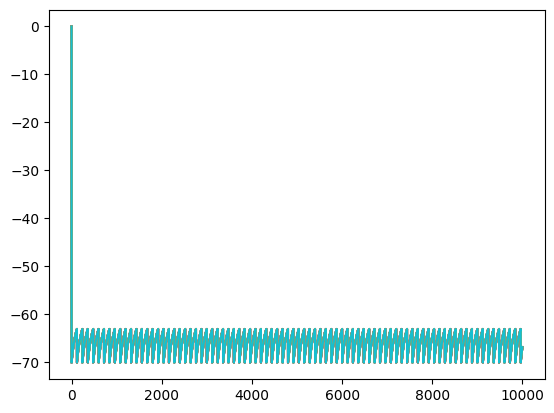

In [240]:
cluster1 = NeuralCluster(10, 0.1) # initialize cluster one 
cluster1.set_input(1)

V0 = np.zeros(cluster1.N)
V0[0] = -70 
cluster1.compute_dynamics_lif(V0, 1000, 0.1)
test = plt.plot(cluster1.V)
  

In [241]:
cluster1 = NeuralCluster(1000, 0.1) # initialize cluster one 
cluster1.set_input(1)

V0 = np.zeros(cluster1.N)
V0[0] = -70 
cluster1.compute_dynamics_lif(V0, 100, 0.1)

cluster2 = NeuralCluster(1000, 0.1) # initialize cluster one 

Computing dynamics steps: 100%|██████████| 999/999 [00:04<00:00, 218.31it/s]


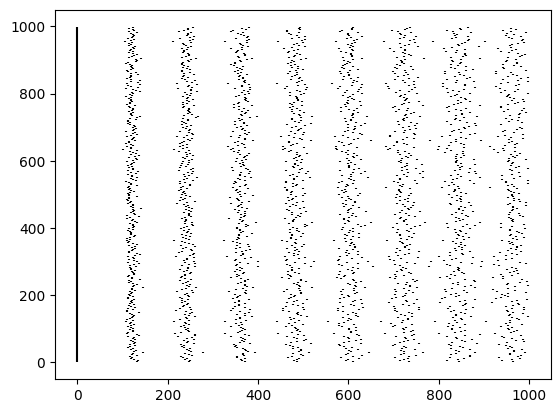

In [230]:
cluster1.plot_raster()

In [274]:
# A class to implement the whole network : two conencted cluseters, linked by inhibitory basket cells. 
# TO BE WRITTEN
class ConnectedClusters(NeuralCluster):
    def __init__(self, N1, N2, n_baskets, inhib=-10):
        self.N1 = N1
        self.N2 = N2
        self.inhibition_strength = inhib
        self.n_baskets = n_baskets
        # Cluster 1
        self.cluster1 = NeuralCluster(N1, 0.1)
        # Cluster 2
        self.cluster2 = NeuralCluster(N2, 0.1)
        # Basket cell affectation array: to each neuron in cluster1/2 correspond one basket cell. Size 2xN.
        self.basket_affectation = np.concatenate([np.random.randint(0, n_baskets, size=N1),
                                                  np.random.randint(0, n_baskets, size=N2)])
        
        super().__init__(N1 + N2 + n_baskets, 0)
        self.w = np.empty((N1 + N2 + n_baskets, N1 + N2 + n_baskets))
        for i in range(N1):
            b = np.zeros(n_baskets)
            b[self.basket_affectation[i]] = inhib
            self.w[i] = np.concatenate([self.cluster1.w[i], np.zeros(N2), b])
        for i in range(N2):
            b = np.zeros(n_baskets)
            b[self.basket_affectation[i]] = inhib
            self.w[N1+i] = np.concatenate([np.zeros(N1), self.cluster2.w[i], b])
        for i in range(n_baskets):
            self.w[N1+N2+i] = np.concatenate([np.where(self.basket_affectation==i, 1, 0),
                                            np.zeros(n_baskets)])

    def compute_dynamics(self, V0, T, dt):
        super().compute_dynamics_lif(V0, T, dt)
        
        self.cluster1.V = self.V[:, :self.N1]
        self.cluster2.V = self.V[:, self.N1:self.N1+self.N2]


        self.cluster1.spike_trains = self.spike_trains[:, :self.N1]
        self.cluster2.spike_trains = self.spike_trains[:, self.N1:self.N1+self.N2]
   
    
    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spike_trains[:,i]
            event.append(np.nonzero(st)[0])
        colors=np.concatenate([np.full(self.N1, 'k'), np.full(self.N2, 'b'), np.full(self.n_baskets, 'r')])
        plt.eventplot(event, colors=colors, zorder = 0)

In [275]:
N1 = 100
N2 = 100
n_baskets = 25

model = ConnectedClusters(N1, N2, n_baskets)
I = 5* np.concatenate([np.ones(N1), np.zeros(N2 + n_baskets)])
model.set_input(I)
V0 = np.concatenate([10*np.random.rand(N1 + N2), np.zeros(n_baskets)])
model.compute_dynamics(V0, 10, 0.001)

Computing dynamics steps: 100%|██████████| 9999/9999 [00:14<00:00, 686.22it/s] 


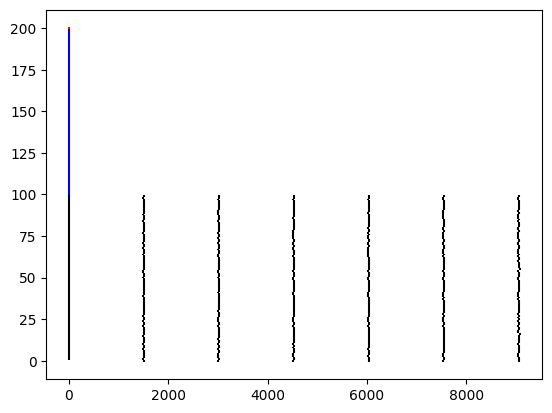

In [272]:
model.plot_raster()

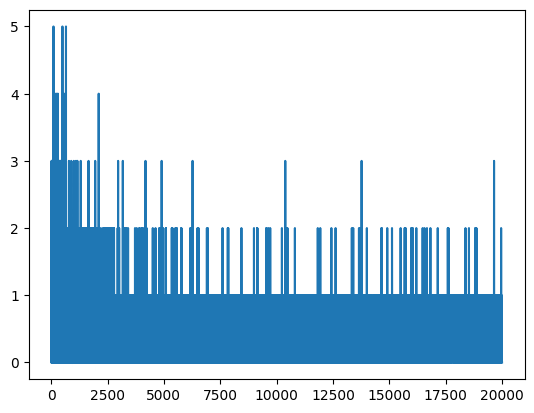

In [8]:
plt.plot(model.spike_count)

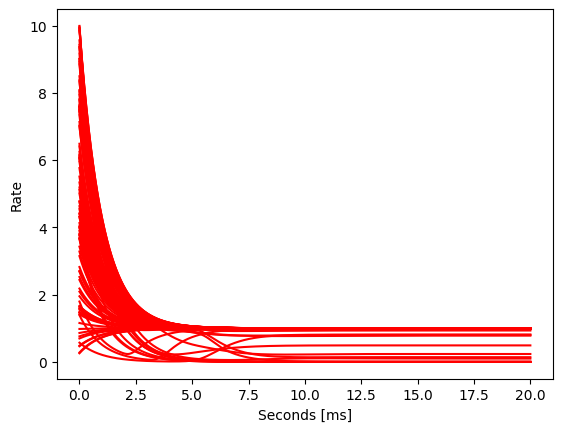

In [9]:
plot_dynamics(model.cluster1, color='r')